In [1]:
import torch
import pandas as pd
import numpy as np
import random
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [109]:
class NeuralNetwork(nn.Module): #model architecture
    def __init__(self):
        super().__init__()
        #self.flatten = nn.Flatten()
        self.stack1 = nn.Sequential(nn.Linear(784,16),nn.ReLU(),nn.Linear(16,8),nn.ReLU())
        self.add_stack1 = nn.Sequential(nn.Linear(8,8),nn.ReLU())
        self.stack2 = nn.Sequential(nn.Linear(784,16),nn.ReLU(),nn.Linear(16,12),nn.ReLU(),nn.Linear(12,8),nn.ReLU())
        self.final = nn.Linear(16,10)
        
    def forward(self,x):
        #x = self.flatten(x)
        add1_ = self.stack1(x)
        add2_ = self.add_stack1(add1_)
        out1 = add1_ + add2_
        out2 = self.stack2(x)
        final_out = torch.concat([out1,out2],dim = 1)
        pred = self.final(final_out)
        return pred


In [127]:

def fw1(index): #loss calculation
        logits = NNN(torch.tensor(norm_features_file[index:index+1].to_numpy(), dtype=torch.float32))
        target = torch.tensor(target_file[index:index+1].to_numpy(), dtype=torch.long)
        loss = F.cross_entropy(logits,target[0],label_smoothing = 0.12)
        y_pred = F.softmax(logits,dim=1)
        #print(F.cross_entropy(logits[0],target[0]),'loss with logits[0]','\n')
        return loss,y_pred

In [128]:
def gen(index): #new data feeding and prediction
    logits = NNN(torch.tensor(norm_features_file[index:index+1].to_numpy(), dtype=torch.float32))
    target = torch.tensor(target_file[index:index+1].to_numpy(), dtype=torch.long)
    loss = F.cross_entropy(logits,target[0],label_smoothing = 0.12) #adding label smoothing 
    y_pred = F.softmax(logits,dim=1)
    predicted_index =  torch.multinomial(y_pred[0], num_samples=1)
    print(y_pred)
    return loss,predicted_index,target,y_pred

In [9]:
ogl_file = pd.read_csv('/Users/admin/.cache/kagglehub/datasets/zalando-research/fashionmnist/versions/4/fashion-mnist_train.csv')
features_file = ogl_file.iloc[:,1:]
target_file = ogl_file.iloc[:,[0]] # separating target file and features file

In [10]:
norm_features_file = pd.DataFrame() #normalising features_file
for i in features_file.columns:
    norm_features_file[i]  = (features_file[i]  - features_file[i].mean())/features_file[i].std()

/var/folders/cq/8d6xzvyx5ndc07c2_z7wjhnc0000gn/T/ipykernel_61812/3778067703.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  norm_features_file[i]  = (features_file[i]  - features_file[i].mean())/features_file[i].std()
/var/folders/cq/8d6xzvyx5ndc07c2_z7wjhnc0000gn/T/ipykernel_61812/3778067703.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  norm_features_file[i]  = (features_file[i]  - features_file[i].mean())/features_file[i].std()
/var/folders/cq/8d6xzvyx5ndc07c2_z7wjhnc0000gn/T/ipykernel_61812/3778067703.py:3: Performa

In [112]:
NNN = NeuralNetwork()
optimizer = torch.optim.AdamW(NNN.parameters(), lr=0.001)

In [124]:
c=0
error_list = []
#calculating loss
for index in range(0,50000):
        
        #optimizer = torch.optim.AdamW(NNN.parameters(), lr=index*(10**(-3)))
        loss,ypred  =  fw1(index)
        error_list.append(loss.item())
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        c+=1
        if c%1000==0:
            pass
            print(loss.item())
    

0.0003122795606032014
1.9248254299163818
0.0001006075763143599
0.0047912076115608215
0.9253357648849487
0.0019776327535510063
1.6886787414550781
0.001046467456035316
0.05618220195174217
0.002725341124460101
0.0030107428319752216
0.5427393913269043
0.0003051292151212692
0.01734047941863537
0.0027469778433442116
0.0056167165748775005
0.006841922644525766
0.0005265279905870557
0.5428896546363831
0.00028761065914295614
0.25827351212501526
0.00045062878052704036
0.0009872806258499622
0.18249940872192383
4.410646579344757e-05
0.0008992680232040584
0.0006264869589358568
0.23706981539726257
0.0015278107021003962
0.003921914380043745
0.1371583193540573
0.034963421523571014
0.1351405531167984
0.09177351742982864
0.008266046643257141
0.06288507580757141
0.000364713923772797
0.060117024928331375
0.0014405598631128669
0.80189448595047
0.15562982857227325
0.5727770924568176
0.01115420088171959
0.310257226228714
4.5536911784438416e-05
0.18881091475486755
4.5432891845703125
0.004377901088446379
0.1424

In [96]:
c_t = 0
cal_list = []
optimizer.zero_grad(set_to_none=True)
#trying to predict on unseen data
for index in range(50000,50501):
    loss,ypred,target,final_logits  =  gen(index)
    cal_list.append(final_logits[0].detach().numpy())
    if ypred.item()==target.item():
        c_t+=1


tensor([[0.0146, 0.0154, 0.3058, 0.0324, 0.4335, 0.0158, 0.1403, 0.0130, 0.0148,
         0.0141]], grad_fn=<SoftmaxBackward0>)
tensor([[0.0130, 0.0086, 0.0125, 0.0074, 0.0089, 0.0186, 0.0067, 0.2350, 0.0130,
         0.6764]], grad_fn=<SoftmaxBackward0>)
tensor([[0.0020, 0.0013, 0.0040, 0.0023, 0.0065, 0.0025, 0.0067, 0.0020, 0.9713,
         0.0013]], grad_fn=<SoftmaxBackward0>)
tensor([[6.8843e-04, 1.0538e-03, 2.6504e-02, 4.7470e-03, 9.4279e-01, 8.6370e-03,
         6.3422e-03, 2.9444e-03, 4.9840e-03, 1.3097e-03]],
       grad_fn=<SoftmaxBackward0>)
tensor([[0.0105, 0.0148, 0.7993, 0.0136, 0.0945, 0.0111, 0.0334, 0.0073, 0.0101,
         0.0053]], grad_fn=<SoftmaxBackward0>)
tensor([[0.0093, 0.8585, 0.0141, 0.0189, 0.0182, 0.0154, 0.0205, 0.0162, 0.0135,
         0.0154]], grad_fn=<SoftmaxBackward0>)
tensor([[0.0037, 0.0038, 0.0977, 0.0157, 0.8203, 0.0123, 0.0271, 0.0068, 0.0086,
         0.0041]], grad_fn=<SoftmaxBackward0>)
tensor([[0.0118, 0.0090, 0.0124, 0.0092, 0.0084, 0.0345, 

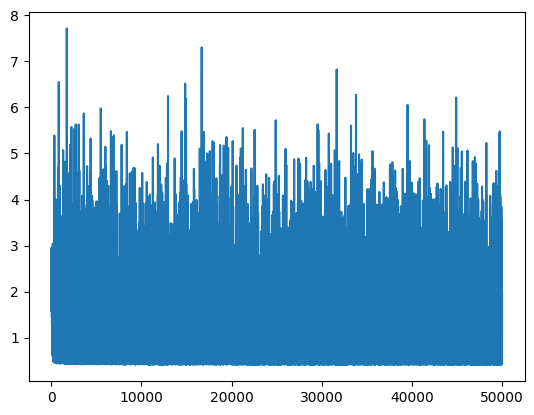

In [113]:
#label smoothing = alpha = 0.08
plt.plot(error_list[:]) 
plt.show()

In [108]:
print(min(error_list),max(error_list))

0.41778329014778137 7.715089321136475


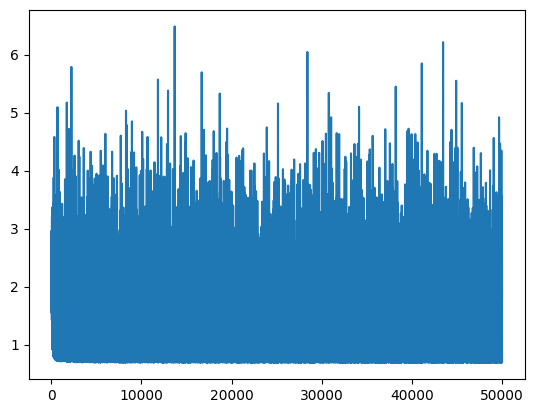

In [115]:
#label smoothing = alpha = 0.15
plt.plot(error_list[:]) 
plt.show()

In [116]:
print(min(error_list),max(error_list))

0.693270742893219 6.483087062835693


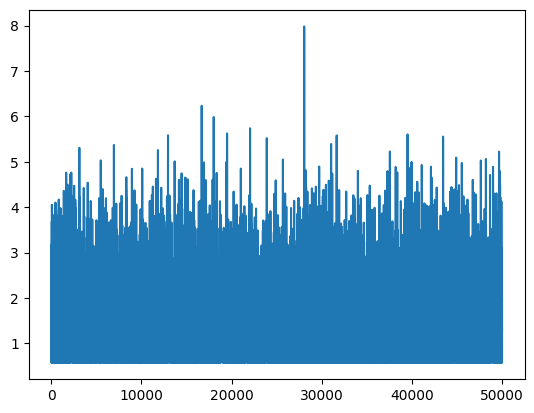

In [120]:
#label smoothing = alpha = 0.12
plt.plot(error_list[:]) 
plt.show()

In [121]:
print(min(error_list),max(error_list))

0.5799041390419006 7.97945499420166


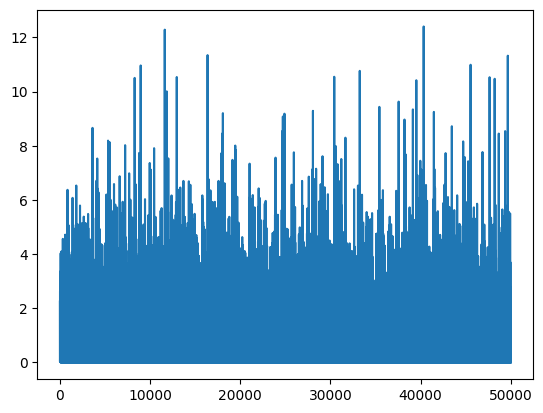

In [125]:
#wihtout label smoothing
plt.plot(error_list[:]) 
plt.show()

In [126]:
print(min(error_list),max(error_list))

0.0 12.401473999023438
